Dropdown(description='Team:', index=13, layout=Layout(width='350px'), options=('AFC Hornchurch', 'AFC Telford …

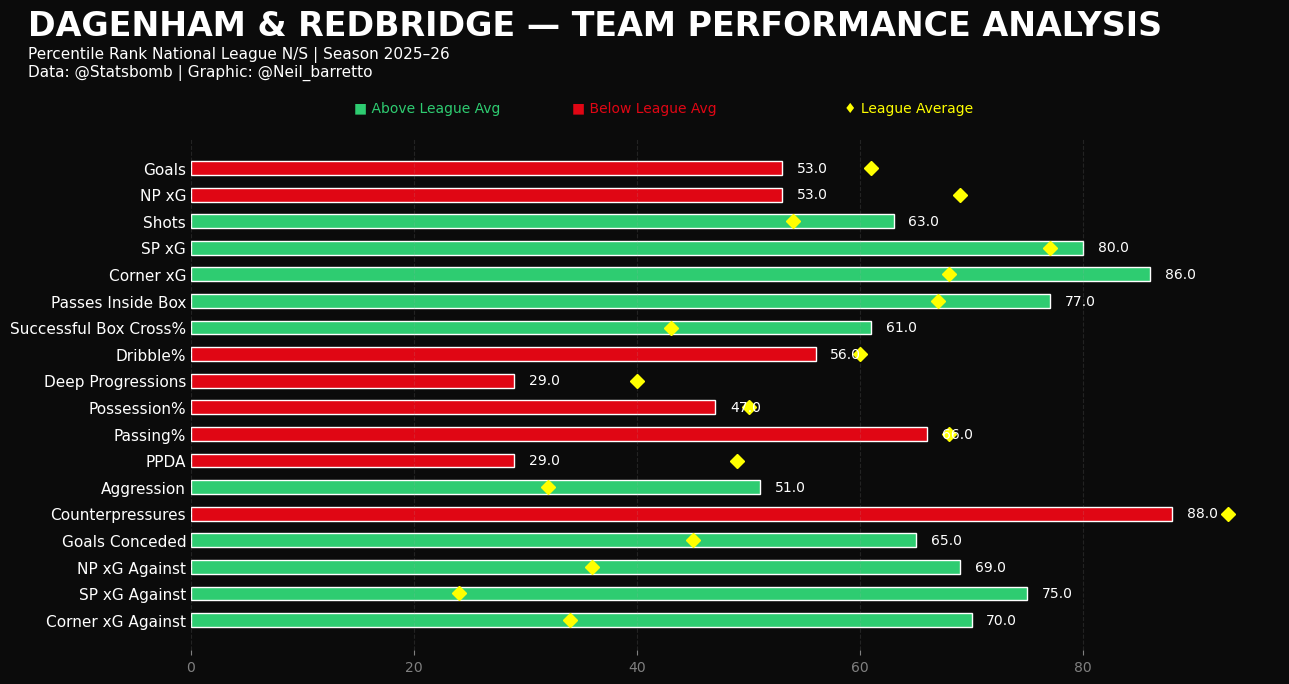

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
import ipywidgets as widgets
from IPython.display import display, clear_output
import os

# -------------------- FILE PATHS (LOCAL) --------------------
DATA_FILE = "League_Team_Stats (5).csv"
LOGO_FILE = "Dagenham_and_Redbridge_FC_crest.svg.png"
OUTPUT_FOLDER = "outputs"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# -------------------- LOAD DATA --------------------
df = pd.read_csv(DATA_FILE)
df.columns = df.columns.str.strip()

# -------------------- METRIC ORDER --------------------
metrics = [
    "Goals", "NP xG", "Shots", "SP xG", "Corner xG",
    "Passes Inside Box", "Successful Box Cross%", "Dribble%", "Deep Progressions",
    "Possession%", "Passing%", "PPDA", "Aggression", "Counterpressures",
    "Goals Conceded", "NP xG Against", "SP xG Against", "Corner xG Against"
]

# -------------------- LEAGUE & TEAM DATA --------------------
league_row = df[df["Team Name"] == "League Average"].iloc[0]
team_names = sorted(df[df["Team Name"] != "League Average"]["Team Name"].unique())

# -------------------- DROPDOWN --------------------
team_selector = widgets.Dropdown(
    options=team_names,
    value=team_names[0],
    description="Team:",
    layout=widgets.Layout(width="350px")
)

# -------------------- PLOT FUNCTION --------------------
def plot_team(selected_team):
    clear_output(wait=True)
    display(team_selector)

    team_row = df[df["Team Name"] == selected_team].iloc[0]

    team_values = team_row[metrics].values.astype(float)
    league_values = league_row[metrics].values.astype(float)

    colors = ["#2ecc71" if t >= l else "#e00614"
              for t, l in zip(team_values, league_values)]

    fig, ax = plt.subplots(figsize=(13, 7))
    fig.patch.set_facecolor("#0b0b0b")
    ax.set_facecolor("#0b0b0b")

    y = np.arange(len(metrics))
    ax.barh(y, team_values, height=0.52,
            color=colors, edgecolor="white", linewidth=1)

    # League average markers
    for i, avg in enumerate(league_values):
        ax.plot(avg, i, marker="D", markersize=7,
                color="#FFFF00", zorder=3)

    # Value labels
    for i, val in enumerate(team_values):
        ax.text(val + max(team_values) * 0.015, i, f"{val:.1f}",
                va="center", ha="left", color="white", fontsize=10)

    ax.set_yticks(y)
    ax.set_yticklabels(metrics, color="white", fontsize=11)
    ax.invert_yaxis()
    ax.tick_params(axis="x", colors="gray")
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="x", linestyle="--", alpha=0.15)

    for spine in ax.spines.values():
        spine.set_visible(False)

    # Titles
    ax.text(-0.15, 1.20,
            f"{selected_team.upper()} — TEAM PERFORMANCE ANALYSIS",
            transform=ax.transAxes, color="white",
            fontsize=24, fontweight="bold")

    ax.text(-0.15, 1.12,
            "Percentile Rank National League N/S | Season 2025–26\n"
            "Data: @Statsbomb | Graphic: @Neil_barretto",
            transform=ax.transAxes, color="white", fontsize=11)

    # Logo
    if os.path.exists(LOGO_FILE):
        try:
            logo = mpimg.imread(LOGO_FILE)
            imagebox = OffsetImage(logo, zoom=0.25)
            ab = AnnotationBbox(imagebox, (0.97, 1.15),
                                xycoords="axes fraction", frameon=False)
            ax.add_artist(ab)
        except:
            pass

    # Legend
    ax.text(0.15, 1.05, "■ Above League Avg",
            transform=ax.transAxes, color="#2ecc71", fontsize=10)
    ax.text(0.35, 1.05, "■ Below League Avg",
            transform=ax.transAxes, color="#e00614", fontsize=10)
    ax.text(0.60, 1.05, "♦ League Average",
            transform=ax.transAxes, color="#FFFF00", fontsize=10)

    # Save
    filename = f"{selected_team.replace(' ', '_')}_Team_Performance.png"
    save_path = os.path.join(OUTPUT_FOLDER, filename)

    plt.savefig(save_path, dpi=300, bbox_inches="tight",
                facecolor=fig.get_facecolor())

    print(f"\n✅ Saved file: {save_path}\n")

    plt.tight_layout()
    plt.show()

# -------------------- START --------------------
plot_team(team_selector.value)
team_selector.observe(lambda change: plot_team(change["new"]), names="value")